In [1]:
from scipy import constants as const
import numpy as np
from matplotlib import pyplot as plt

import oreonspy as op

plt.rcParams['figure.figsize'] = [10, 6]

In [2]:
t_a = 0.1
r_a = 0.9
r_b = 0.9
L = 3000  # m
T = L/const.c  # s
E_in_avg = 1  #
lambd = 1064e-9  # m
k = 2*np.pi / lambd

Loss = 1. - np.power(t_a,2) - np.power(r_a,2)
if  Loss < 0.:
    print("Attenti ai valori")
else:
    print("Loss: {0}".format(Loss))

Loss: 0.17999999999999994


In [3]:
def N_eff(r_a, r_b):
    '''
    Effective number of photon round trips in a FabryPerot cavity (Rakhmanov Eq. 1.57)
    '''
    return 1./np.abs(np.log(r_a*r_b))

In [4]:
def F():
    '''
    Coefficient of finesse
    '''
    return 4.*r_a*r_b / np.power(1.-r_a*r_b, 2)

def tau_s():
    '''
    Formula equivalent to Eq. 2.17 (Rakhmanov)

    return 2. * T * N_eff(r_a, r_b)
    '''
    return F() * L / (np.pi * const.c)

def Finesse(F):
    '''
    Finesse
    '''
    return np.sqrt(F) * np.pi / 2.

In [5]:
print("Coefficient of finesse: {0:.2f}".format(F()))

print("Tau_s: {0}".format(tau_s()))

print("Finesse: {0}".format(Finesse(F())))

Coefficient of finesse: 89.75
Tau_s: 0.0002858831030486214
Finesse: 14.881228359109551


## Critical velocity

$v_\mathrm{cr} = \frac{\lambda}{2\tau\mathcal{F}}$

where $\tau$ is the storage time:

$\tau = 2 T N_\mathrm{eff}$

In [6]:
def tau():
    return 2. * T * N_eff(r_a, r_b)

In [7]:
def v_cr():
    return lambd / (2. * Finesse(F()) * tau())  # In [m/s]!

In [8]:
v_cr()

0.0003764004958010008

## Airy function

In [9]:
def Airy(F, phi):
    return 1. / (1. + F * np.sin(phi)**2)

In [10]:
def Airy_phase(Ein, V, t):
    return t_a*Ein/(1.-r_a*r_b*np.exp(-2.j*k*V*t))

## Cavity gain

$E = g A$

where $g$ ia the amplitude gain of the Fabry-Perot cavity:

$g = \frac{t_a}{1-r_a r_b}$

Power gain:

$P = g^2 P_\mathrm{in}$

In [11]:
def gain():
    return t_a / (1. - r_a*r_b)

## Cavity parameters summary

In [12]:
N_eff(r_a, r_b)

4.745610790514953

In [13]:
T

1.0006922855944561e-05

In [14]:
gain()

0.5263157894736844

## Some cases of $d(t)$

* $d(t) = const.$
* $d(t) = A\sin(2\pi f t)$
* $d(t) = arb(t)$ -- arbitrary function of time

In [15]:
v = .01*v_cr()  # m/s

#v = 0.00037640

def d(v,t,L):
    """
    Calculate the displacement based on velocity, time and initial length.
    """
    # Constant
    #return 2

    # Linear    
    #c = 1.
    return v*t + L

    # Sinusoidal
    A = 1.e-7
    f = 200.e6  # Hz
    #return A*np.sin(2.*np.pi*f*t)

In [16]:
def E_in(t):
    return 1.
    #return A*np.sin(2.*np.pi*f*t)

In [17]:
def x_a(t):
    return 0.0

In [18]:
def S_n(t, n, T, L):
    '''
    2 S_n is the optical path length for a photon which completed n round trips in the cavity.
    
    t - time
    n - "order" of S function (number of round-trips)
    T - half of the cavity round-trip time
    '''
    S = 0
    for p in np.arange(1, n+1, 1):
        S = S + d(v, t - 2.*T*p, L)
    return S

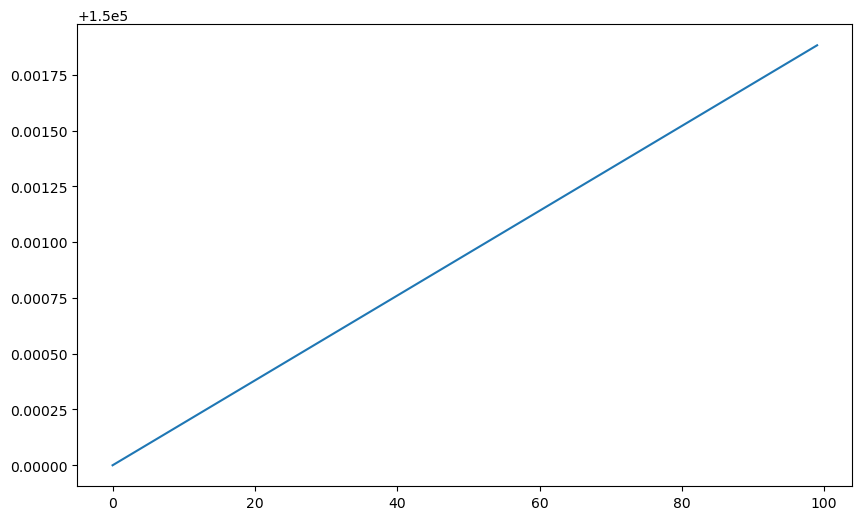

In [19]:
tdata = np.linspace(0,10,100)

res = np.zeros(100)

for idx, t in enumerate(tdata):
    res[idx] = S_n(t, 50, T, L)
    #print(dat)
#print(y)

plt.plot(res)

## Implementation of Eq. 1.51

In [24]:
N = 100  # Seems reasonable to sum up to 5 to 10 N_eff.
n = np.arange(0, N+1, 1)
rarbn = np.power(r_a*r_b, n)

def E_old(t, v, N=0, recursion_level=0):
    '''
    Implementation of Eq. 1.51 from "Dynamics of Laser Interferometric Gravitational Wave Detectors" PhD thesis by M. Rakhmanov
    '''

    if recursion_level > 10:  # TODO: Verify the accuracy!
        raise RecursionError(f"Maximum recursion depth reached at level {recursion_level}")
        #return 0.
        
    global t_a, r_a, r_b, T
    
    if N == 0:
        N = int(N_eff(r_a, r_b) * 5)

    '''
    if False:
        print("T_a: {0}".format(t_a))
        print("(r_a*r_b)^2: {0}".format(np.power(r_a*r_b, N)))
        print(k*S_n(t, N, T))
        #print(E(t-2.*N*T, N))# Batch simulation
        print("--------")
    '''
    
    k2j = -2.j*k
    
    Sum = 0
    Sn = 0.
    for idx, p in enumerate(np.arange(1, N+1, 1)):
        Sum = Sum + rarbn[idx] * np.exp(k2j*Sn) * E_in(t-2.*p*T)
        #print("Idx: {0}, p: {1}, Sn: {2}".format(idx, p, Sn))
        d_val = d(v,t - 2.*T*p, L)
        Sn = Sn + d_val
        #print("d: {0}".format(d_val))
        

    try:
        E_last = E(t - 2.*N*T, v, N=N, recursion_level=recursion_level+1)
    except RecursionError:
        #print("Recursion lvl: {0}".format(recursion_level))
        E_last = 0.
        
    res = t_a * Sum + rarbn[N] * np.exp(k2j*Sn) * E_last
    return res


def E(t, v, N=0, recursion_level=0):
    '''
    Recursive implementation of Eq. 1.50 from "Dynamics of Laser Interferometric Gravitational Wave Detectors" PhD thesis by M. Rakhmanov
    '''

    if recursion_level > N:  # TODO: Verify the accuracy!
        raise RecursionError(f"Maximum recursion depth reached at level {recursion_level}")
        
    global t_a, r_a, r_b, T
    
    if N == 0:
        N = int(N_eff(r_a, r_b) * 5)
    
    k2j = -2.j*k

    try:
        E_last = E(t - 2.*T, v, N=N, recursion_level=recursion_level+1)
    except RecursionError:
        #print("Recursion lvl: {0}".format(recursion_level))
        E_last = 0.
        
    res = t_a * E_in(t) + r_a * r_b * np.exp(k2j*d(v, t, L)) * E_last
    return res

In [25]:
class Cavity_recursive:
    c = 299792458.0  # Speed of light in vacuum [m/s]
    

    def E_in(t, fwhm_duration = None, t_peak = None):
        pass

    def d(v, t):
        pass

    def __init__(self, t_a=0.001, T_a=None, r_a=0.99, R_a=None, r_b=0.999, R_b=None, L=3000.0, debug=None, log_file=None):
        if T_a is not None:
            self.t_a = np.sqrt(T_a)
        else:
            self.t_a = t_a
        
        if R_a is not None:
            self.r_a = np.sqrt(R_a)
        else:
            self.r_a = r_a

        if R_b is not None:
            self.r_b = np.sqrt(R_b)
        else:
            self.r_b = r_b
        
        self.__L__ = L  # [m]
        self.T = L / self.c  # [s] half cavity round-trip time


    def N_eff(self):
        '''
        Effective number of photon round trips in a FabryPerot cavity (Rakhmanov Eq. 1.57)
        '''
        return 1./np.abs(np.log(self.r_a*self.r_b))
    

    def F(self):
        '''
        Coefficient of finesse
        '''
        return 4.*self.r_a*self.r_b / np.power(1.-self.r_a*self.r_b, 2)

    def tau_s(self):
        '''
        Formula equivalent to Eq. 2.17 (Rakhmanov)

        return 2. * T * N_eff(r_a, r_b)
        '''
        return self.F() * self.__L__ / (np.pi * const.c)

    def Finesse(self):
        '''
        Finesse
        '''
        return np.sqrt(self.F()) * np.pi / 2.
    
    def tau(self):
        return 2. * self.T * self.N_eff()
    
    def v_cr(self):
        return lambd / (2. * self.Finesse() * self.tau())  # In [m/s]!
    
    def gain(self):
        return self.t_a / (1. - self.r_a*self.r_b)

    def simulation(self, k, E_in, d):
        self.k2j = -2.j*k

        self.N = int(self.N_eff() * 10)

        if self.N < 1:
            self.N = 1

        self.n = np.arange(0, self.N+1, 1)

        self.rarbn = np.power(self.r_a*self.r_b, self.n)

        self.E_in = E_in
        self.d = d


    def sim_step(self, t, v, recursion_level=0):
        '''
        Recursive implementation of Eq. 1.50 from "Dynamics of Laser Interferometric Gravitational Wave Detectors" PhD thesis by M. Rakhmanov
        '''

        if recursion_level > self.N:  # TODO: Verify the accuracy!
            raise RecursionError(f"Maximum recursion depth reached at level {recursion_level}")
        
        try:
            E_last = self.sim_step(t - 2.*self.T, v, recursion_level=recursion_level+1)
        except RecursionError:
            #print("Recursion lvl: {0}".format(recursion_level))
            E_last = 0.
            
        res = self.t_a * self.E_in(t) + self.r_a * self.r_b * np.exp(self.k2j*self.d(v, t, self.__L__)) * E_last
        return res

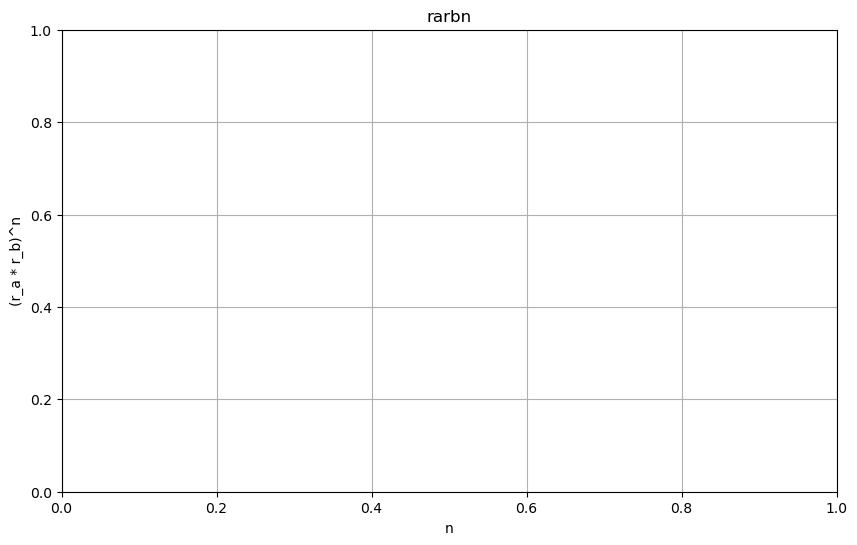

In [26]:
plt.figure()
#plt.plot(n, rarbn, marker='o', ms=3, lw=1)
plt.xlabel("n")
plt.ylabel("(r_a * r_b)^n")
plt.title("rarbn")
plt.grid(True)

In [27]:
E(0.01, v)

(0.05570900667075575-0.010480037754771724j)

## Definition of useful arrays

In [28]:
number_of_points = 3000

Airy_power_data = np.zeros(number_of_points, dtype=np.complex_)

ein = np.zeros(number_of_points, dtype=np.complex_)
eref = np.zeros(number_of_points, dtype=np.complex_) #for the values of the reflected field
dyn = np.zeros(number_of_points, dtype=np.complex_) #for the values of the field inside the cavity in case of lenght scan transient
res_dyn = np.zeros(number_of_points, dtype=np.complex_) #for the values of the cavity field obtained numerically
rt_sim_res = np.zeros(number_of_points, dtype=np.complex_)
res = np.zeros(number_of_points, dtype=np.complex_)


## Automation of the comparison between numerical solution and Airy function with selectable velocity.

The function `simulation_check` aims to automatize the process of compare the numerical simulation with the analitycal solution (Airy function), giving the possibility to choose the velocity of $d(t)$ and compute the right time window for visualizing 2 free spectral range. The correct time window is calculated through the function `time_window`.

In [29]:
def time_window(v, number_of_points):
    t_stop = lambd/v
    return np.linspace(0.,t_stop,number_of_points)

In [30]:
Airy_power_data = Airy(F(), (time_window(v, number_of_points)*k-.2867895)*v)

In [31]:
cavity_finesse_data = np.genfromtxt('../optics/Finesse Test cavity scan.csv', delimiter=',', dtype=complex)
cavity_finesse_tdata = np.linspace(0., lambd/v, np.shape(cavity_finesse_data)[0])

In [32]:
tdata=time_window(v, 3000)
finesse_inter = np.interp(tdata, cavity_finesse_tdata, cavity_finesse_data[:,1]) 

In [33]:
plt.rcParams['figure.figsize'] = [10, 7]

def simulation_check(v, number_of_points):
    tdata=time_window(v, number_of_points)

    # Oreonspy
    cavity = op.Cavity(t_a=t_a , r_a=r_a , r_b=r_b , L=L)
    cavity.simulation(k, 1/(tdata[1]-tdata[0]), E_in_init=1.)
    cavity.print_sim_params()

    # Batch simulation
    cav_test = Cavity_recursive(L=L, r_a=r_a, r_b=r_b, t_a=t_a)
    tau = cav_test.T
    tau = 2.*L/cav_test.c
    print("Tau: {0}".format(tau))
    cav_test.simulation(k, E_in, d)

    for idx, t in enumerate(tdata):
        # Batch simulation
        ein[idx] = E_in(t)
        res[idx] = cav_test.sim_step(t, v)

        # RT simulation
        rt_sim_res[idx],_ = cavity.sim_step(1., 0, lambd/number_of_points)

    zero_airy_phase = 0.2867895
    zero_airy_phase = 0.01905647
    aligned_airy_phase = 0.07221141141141144
    
    Airy_power_data = Airy(F(), (tdata+zero_airy_phase)*k*v)
    
    Airy_phase_data = Airy_phase(1., v, tdata+zero_airy_phase)

    fig, axs = plt.subplots(2)
    plt.subplots_adjust(wspace=8.)
    fig.suptitle(r"Simulators commissioning", fontsize=18)
    axs[0].grid(visible=True)
    axs[0].plot(tdata, np.roll(abs(res)**2,40), label="Batch simulator")
    axs[0].plot(tdata, np.roll(Airy_power_data*gain()**2,1100), label="Airy", ls="--")
    axs[0].plot(tdata, np.roll(abs(rt_sim_res)**2, 100), label="RT simulator")
    axs[0].plot(tdata, np.roll(np.abs(finesse_inter)**2,950), label="Finesse simulation", ls="--")
    axs[0].set_ylabel("power")
    axs[0].set_xlabel("time")
    axs[0].legend()

    axs[1].grid(visible=True)
    axs[1].plot(tdata, np.roll(np.unwrap(np.angle(res, deg=True)*2),40)/2, label="Batch sim. phase")
    axs[1].plot(tdata, np.roll(np.unwrap(np.angle(Airy_phase_data, deg=True)*2),1100)/2, label="Airy phase", ls="--")
    axs[1].plot(tdata, np.roll(np.unwrap(np.angle(rt_sim_res, deg=True)*2),100)/2, label="RT sim. phase")
    axs[1].plot(tdata, np.roll(np.unwrap((np.angle(finesse_inter, deg=True)-90)*2), 950)/2, label="Finesse sim. phase",ls="--")
    axs[1].set_xlabel("time")
    axs[1].set_ylabel("phase")
    axs[1].legend()
    
    plt.legend()


    print(Airy_power_data*gain())
    print(np.angle(Airy_phase_data))

    #plt.savefig("Comparision.pdf")


In [34]:
v = 0.01*v_cr()

print("v: {0:.2e} m/s".format(v))

v: 3.76e-06 m/s


In [35]:
number_of_points

3000

Theta: 1.00e-04 [s]
Cavity RT: 2.00e-05 [s]
Calculation frequency: 9.99e+03 [Hz]
N_eff: 5.00e+00
N: 5
Number of 2T chains: 1
Partial Theta: False
Tau: 2.0013845711889123e-05
[0.03256412 0.03228214 0.032004   ... 0.03313984 0.03284999 0.03256412]
[-0.91847303 -0.91760745 -0.91673125 ... -0.92017175 -0.91932785
 -0.91847303]


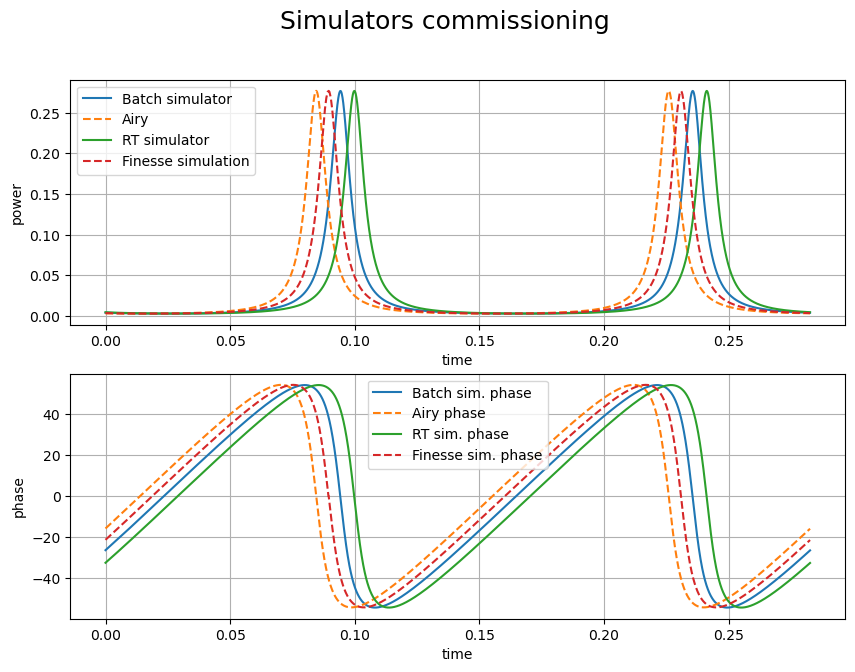

In [36]:
simulation_check(v, number_of_points)

## Plots for various velocities

In [90]:
plt.rcParams['figure.figsize'] = [15, 13]

def simulation_check2(number_of_points):

    rt_sim_res1 = np.zeros(number_of_points, dtype=np.complex_)
    res1 = np.zeros(number_of_points, dtype=np.complex_)
    ein1 = np.zeros(number_of_points, dtype=np.complex_)

    tdata1=time_window(.01*v_cr(), number_of_points)
    cavity_finesse_tdata1 = np.linspace(0., lambd/(.01*v_cr()), np.shape(cavity_finesse_data)[0])

    zero_airy_phase = 0.2867895
    zero_airy_phase = 0.01905647
    aligned_airy_phase = 0.07221141141141144
    
    Airy_power_data1 = Airy(F(), (tdata1+zero_airy_phase)*k*.01*v_cr()).copy()
    
    Airy_phase_data1 = Airy_phase(1., .01*v_cr(), tdata1+zero_airy_phase).copy()
    
    # Oreonspy
    cavity1 = op.Cavity(t_a=t_a , r_a=r_a , r_b=r_b , L=L)
    cavity1.simulation(k, 1/(tdata1[1]-tdata1[0]), E_in_init=1.)
    cavity1.print_sim_params()

    finesse_inter1 = np.interp(tdata1, cavity_finesse_tdata1, cavity_finesse_data[:,1]) 

    # Batch simulation
    cav_test = Cavity_recursive(L=L, r_a=r_a, r_b=r_b, t_a=t_a)
    tau = cav_test.T
    tau = 2.*L/cav_test.c
    print("Tau: {0}".format(tau))
    cav_test.simulation(k, E_in, d)

    for idx, t in enumerate(tdata1):
        # Batch simulation
        ein1[idx] = E_in(t)
        res1[idx] = cav_test.sim_step(t, 0.01*v_cr())
        # RT simulation
        rt_sim_res1[idx],_ = cavity1.sim_step(1., 0, lambd/number_of_points).copy()
    print("Res1 = {0}".format(len(res1)))

    rt_sim_res2 = np.zeros(number_of_points, dtype=np.complex_)
    res2 = np.zeros(number_of_points, dtype=np.complex_)
    ein2 = np.zeros(number_of_points, dtype=np.complex_)
    Airy_power_data2 = np.zeros(number_of_points, dtype=np.complex_)

    tdata2=time_window(v_cr(), number_of_points)
    cavity_finesse_tdata2 = np.linspace(0., lambd/(v_cr()), np.shape(cavity_finesse_data)[0])

    finesse_inter2 = np.interp(tdata2, cavity_finesse_tdata2, cavity_finesse_data[:,1]).copy()

    Airy_power_data2 = Airy(F(), (tdata2+zero_airy_phase)*k*v_cr()).copy()
    
    Airy_phase_data2 = Airy_phase(1., v_cr(), tdata2+zero_airy_phase).copy()

    cavity2 = op.Cavity(t_a=t_a , r_a=r_a , r_b=r_b , L=L)
    cavity2.simulation(k, 1/(tdata2[1]-tdata2[0]), E_in_init=1.)
    cavity2.print_sim_params()

    for idx, t in enumerate(tdata2):
        # Batch simulation
        ein2[idx] = E_in(t)
        res2[idx] = cav_test.sim_step(t, v_cr())
        # RT simulation
        rt_sim_res2[idx],_ = cavity2.sim_step(1., 0, lambd/number_of_points).copy()
        
    print("Res12 = {0}".format(len(res2)))
    

    
    rt_sim_res3 = np.zeros(number_of_points, dtype=np.complex_)
    res3 = np.zeros(number_of_points, dtype=np.complex_)
    ein3 = np.zeros(number_of_points, dtype=np.complex_)
    Airy_power_data3 = np.zeros(number_of_points, dtype=np.complex_)
    
    tdata3=time_window(5*v_cr(), number_of_points)
    cavity_finesse_tdata3 = np.linspace(0., lambd/(5*v_cr()), np.shape(cavity_finesse_data)[0])

    finesse_inter3 = np.interp(tdata3, cavity_finesse_tdata3, cavity_finesse_data[:,1]).copy()

    Airy_power_data3 = Airy(F(), (tdata3+zero_airy_phase)*k*5*v_cr()).copy()
    
    Airy_phase_data3 = Airy_phase(1., 5*v_cr(), tdata3+zero_airy_phase).copy()

    cavity3 = op.Cavity(t_a=t_a , r_a=r_a , r_b=r_b , L=L)
    cavity3.simulation(k, 1/(tdata3[1]-tdata3[0]), E_in_init=1.)
    cavity3.print_sim_params()

    for idx, t in enumerate(tdata3):
        # Batch simulation
        ein3[idx] = E_in(t)
        res3[idx] = cav_test.sim_step(t, 5*v_cr())
        # RT simulation
        rt_sim_res3[idx],_ = cavity3.sim_step(1., 0, lambd/number_of_points).copy()
    print("Res3 = {0}".format(len(res3)))



    #print(Airy_power_data*gain())
    #print(np.angle(Airy_phase_data)

    return res1, res2, res3, Airy_power_data1,Airy_power_data2,Airy_power_data3, Airy_phase_data1,Airy_phase_data2,Airy_phase_data3, rt_sim_res1,rt_sim_res2,rt_sim_res3, finesse_inter1,finesse_inter2,finesse_inter3, tdata1,tdata2,tdata3

If you want to keep your original phase with pi-periodicity, you should first double the phase, unwrap it, then divide it by two.

In [91]:
res1, res2, res3, Airy_power_data1,Airy_power_data2,Airy_power_data3, Airy_phase_data1,Airy_phase_data2,Airy_phase_data3, rt_sim_res1,rt_sim_res2,rt_sim_res3, finesse_inter1,finesse_inter2,finesse_inter3, tdata1,tdata2,tdata3=simulation_check2(number_of_points)

Theta: 1.00e-04 [s]
Cavity RT: 2.00e-05 [s]
Calculation frequency: 9.99e+03 [Hz]
N_eff: 5.00e+00
N: 5
Number of 2T chains: 1
Partial Theta: False
Tau: 2.0013845711889123e-05


AttributeError: 'tuple' object has no attribute 'copy'

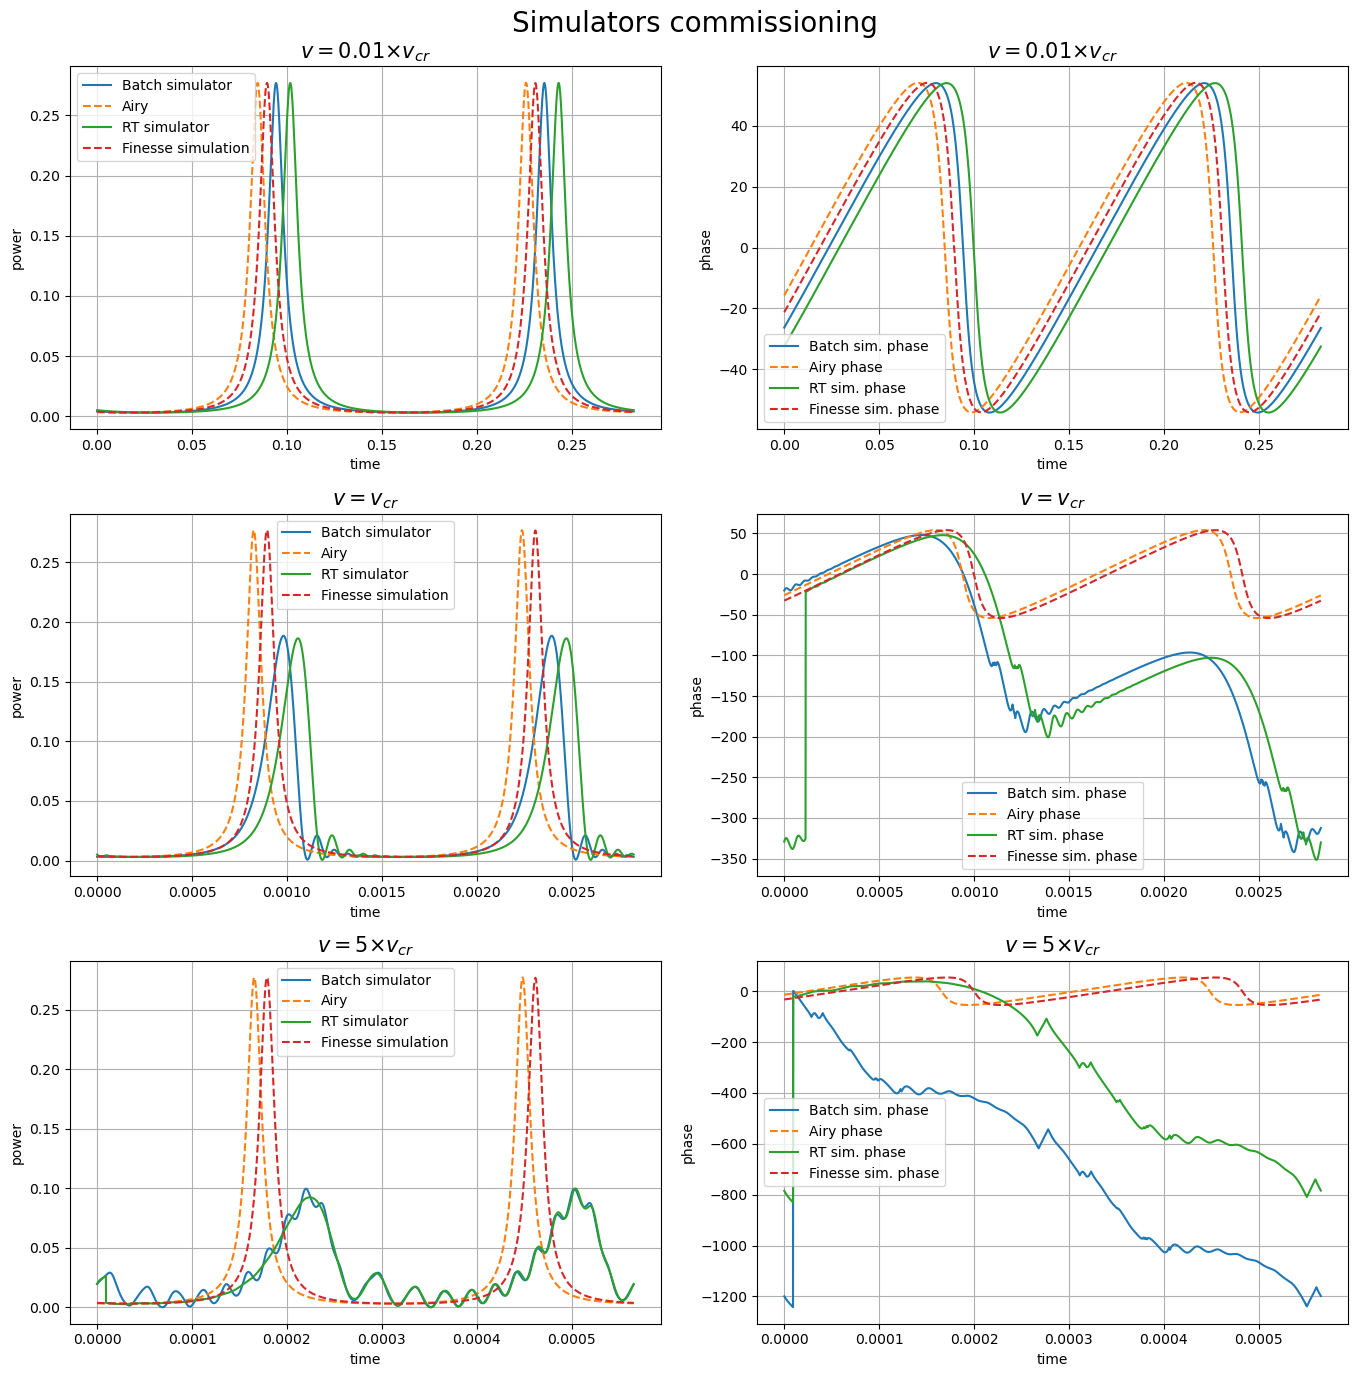

In [97]:
plt.rcParams['figure.figsize'] = [14,14]
fig, axs = plt.subplots(3,2)
plt.subplots_adjust(wspace=5.)
fig.suptitle(r"Simulators commissioning", fontsize=20)

#Plot for v=0.1*v_cr1
axs[0,0].grid(visible=True)
axs[0,0].set_title(r"$v = 0.01 $$ \times$$ v_{cr}$ ", fontsize=15)
axs[0,0].plot(tdata1, np.roll(abs(res1)**2,40), label="Batch simulator")
axs[0,0].plot(tdata1, np.roll(Airy_power_data1*gain()**2,1100), label="Airy", ls="--")
axs[0,0].plot(tdata1, np.roll(abs(rt_sim_res1)**2, 120), label="RT simulator")
axs[0,0].plot(tdata1, np.roll(np.abs(finesse_inter1)**2,950), label="Finesse simulation", ls="--")
axs[0,0].set_ylabel("power")
axs[0,0].set_xlabel("time")
axs[0,0].legend()

axs[0,1].grid(visible=True)
axs[0,1].set_title(r"$v = 0.01 $$ \times$$ v_{cr}$ ", fontsize=15)
axs[0,1].plot(tdata1, np.roll(np.unwrap(np.angle(res1, deg=True)*2),40)/2, label="Batch sim. phase")
axs[0,1].plot(tdata1, np.roll(np.unwrap(np.angle(Airy_phase_data1, deg=True)*2),1100)/2, label="Airy phase", ls="--")
axs[0,1].plot(tdata1, np.roll(np.unwrap(np.angle(rt_sim_res1, deg=True)*2),100)/2, label="RT sim. phase")
axs[0,1].plot(tdata1, np.roll(np.unwrap((np.angle(finesse_inter1, deg=True)-90)*2), 950)/2, label="Finesse sim. phase",ls="--")
axs[0,1].set_xlabel("time")
axs[0,1].set_ylabel("phase")
axs[0,1].legend()

#Plots for v=v_cr
axs[1,0].grid(visible=True)
axs[1,0].set_title(r"$v = v_{cr}$ ", fontsize=15)
axs[1,0].plot(tdata2, np.roll(abs(res2)**2,0), label="Batch simulator")
axs[1,0].plot(tdata2, np.roll(Airy_power_data2*gain()**2,100), label="Airy", ls="--")
axs[1,0].plot(tdata2, np.roll(abs(rt_sim_res2)**2, 80), label="RT simulator")
axs[1,0].plot(tdata2, np.roll(np.abs(finesse_inter2)**2,950), label="Finesse simulation", ls="--")
axs[1,0].set_ylabel("power")
axs[1,0].set_xlabel("time")
axs[1,0].legend()
    

axs[1,1].grid(visible=True)
axs[1,1].set_title(r"$v = v_{cr}$ ", fontsize=15)
axs[1,1].plot(tdata2, np.roll(np.unwrap(np.angle(res2, deg=True)*2),0)/2, label="Batch sim. phase")
axs[1,1].plot(tdata2, np.roll(np.unwrap(np.angle(Airy_phase_data2, deg=True)*2),220)/2, label="Airy phase", ls="--")
axs[1,1].plot(tdata2, np.roll(np.unwrap(np.angle(rt_sim_res2, deg=True)*2),120)/2, label="RT sim. phase")
axs[1,1].plot(tdata2, np.roll(np.unwrap((np.angle(finesse_inter2, deg=True)-90)*2), 1060)/2, label="Finesse sim. phase",ls="--")
axs[1,1].set_xlabel("time")
axs[1,1].set_ylabel("phase")
axs[1,1].legend()


#Plots for v=5*v_cr
axs[2,0].grid(visible=True)
axs[2,0].set_title(r"$v = 5 $$ \times$$ v_{cr}$ ", fontsize=15)
axs[2,0].plot(tdata3, np.roll(abs(res3)**2,50), label="Batch simulator")
axs[2,0].plot(tdata3, np.roll(Airy_power_data3*gain()**2,0), label="Airy", ls="--")
axs[2,0].plot(tdata3, np.roll(abs(rt_sim_res3)**2, 50), label="RT simulator")
axs[2,0].plot(tdata3, np.roll(np.abs(finesse_inter3)**2,950), label="Finesse simulation", ls="--")
axs[2,0].set_ylabel("power")
axs[2,0].set_xlabel("time")
axs[2,0].legend()

axs[2,1].grid(visible=True)
axs[2,1].set_title(r"$v = 5 $$ \times$$ v_{cr}$ ", fontsize=15)
axs[2,1].plot(tdata3, np.roll(np.unwrap(np.angle(res3, deg=True)*2),50)/2, label="Batch sim. phase")
axs[2,1].plot(tdata3, np.roll(np.unwrap(np.angle(Airy_phase_data3, deg=True)*2),0)/2, label="Airy phase", ls="--")
axs[2,1].plot(tdata3, np.roll(np.unwrap(np.angle(rt_sim_res3, deg=True)*2),50)/2, label="RT sim. phase")
axs[2,1].plot(tdata3, np.roll(np.unwrap((np.angle(finesse_inter3, deg=True)-90)*2), 1060)/2, label="Finesse sim. phase",ls="--")
axs[2,1].set_xlabel("time")
axs[2,1].set_ylabel("phase")
axs[2,1].legend()

fig.tight_layout()
plt.savefig("Comparision.pdf")

In [74]:
(np.abs(finesse_inter)**2 - np.abs(rt_sim_res)**2).sum()/float(rt_sim_res.size)

7.58191326153496e-05

# TODO:
    1. Delay factor (0.013 in Adata)
    2. Reproduce FigureFigure2.5 (Rakhmanov)

## Delay factor
The delay factor is 0.2867895 but, in order to have a better match between Airy data and numerical values, it is possibile to compute it taking the instants in which we have the maximum value from Airy data and numerical solution and then effectuate the difference. Moreover in the function `simulation_check` we add the factor 0.2867895 to $k*t$ instead of just $t$. Here the delay factor that will be calculated has to be added to $t$ to have a perfect match.

In [41]:
np.max(abs(res)**2/gain())

0.5260768158828789

In [42]:
np.max(Airy_power_data*gain())

0.5263157894186402

In [44]:
tdata=time_window(v, number_of_points)
t_E=0
t_A=0
for idx, t in enumerate(tdata):
    # Batch simulation
    ein[idx] = E_in(t)
    res[idx] = E(t, v, N=25)
    Airy_power_data[idx] = Airy(F(), (t*k-.2867895)*v)
    if abs(res[idx])**2/gain() == 0.5249204171102564:
        t_E=t
    if Airy_power_data[idx]*gain() == 0.5263157890851667:
        t_A=t

In [45]:
print(t_E)

0


In [46]:
print(t_A)

0


In [47]:
delay=t_A-t_E
print(delay)

0


In [50]:
def simulation_check3(v, number_of_points, type_d):


    tdata=time_window(v, number_of_points)

    for idx, t in enumerate(tdata):
        # Batch simulation
        ein[idx] = E_in(t)
        res[idx] = E(t, v, N=50)
    
    Adata = Airy(F(), (tdata+delay)*k*v)

    plt.figure()
    plt.plot(tdata, abs(res)**2/gain(), label="Numerical magn")
    plt.plot(tdata, Adata*gain(), label="Airy")
    plt.xlabel("Time [s]")
    plt.legend()

    plt.figure()
    plt.plot(tdata, np.unwrap(np.angle(np.roll(res,177), deg=True)*2)/2, label="Numerical phase")
    #plt.plot(tdata, np.angle(res, deg=True), label="Numerical phase")
    plt.plot(tdata, np.unwrap(np.angle(Airy_phase(ein, v, tdata), deg=True)*2)/2, label="Analytical phase")
    plt.xlabel("Time [s]")
    plt.legend()

    return plt.show()

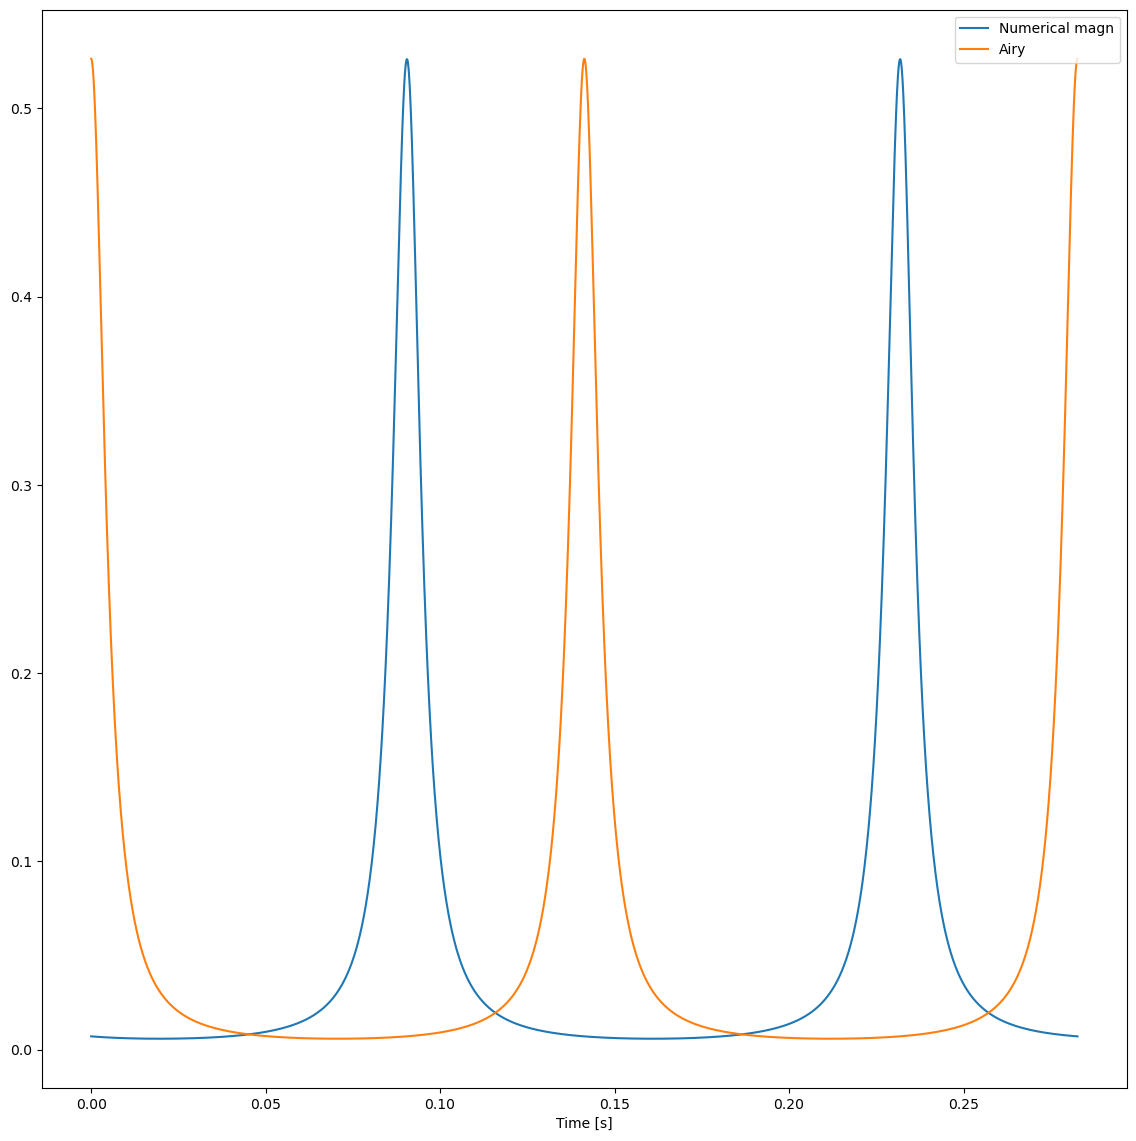

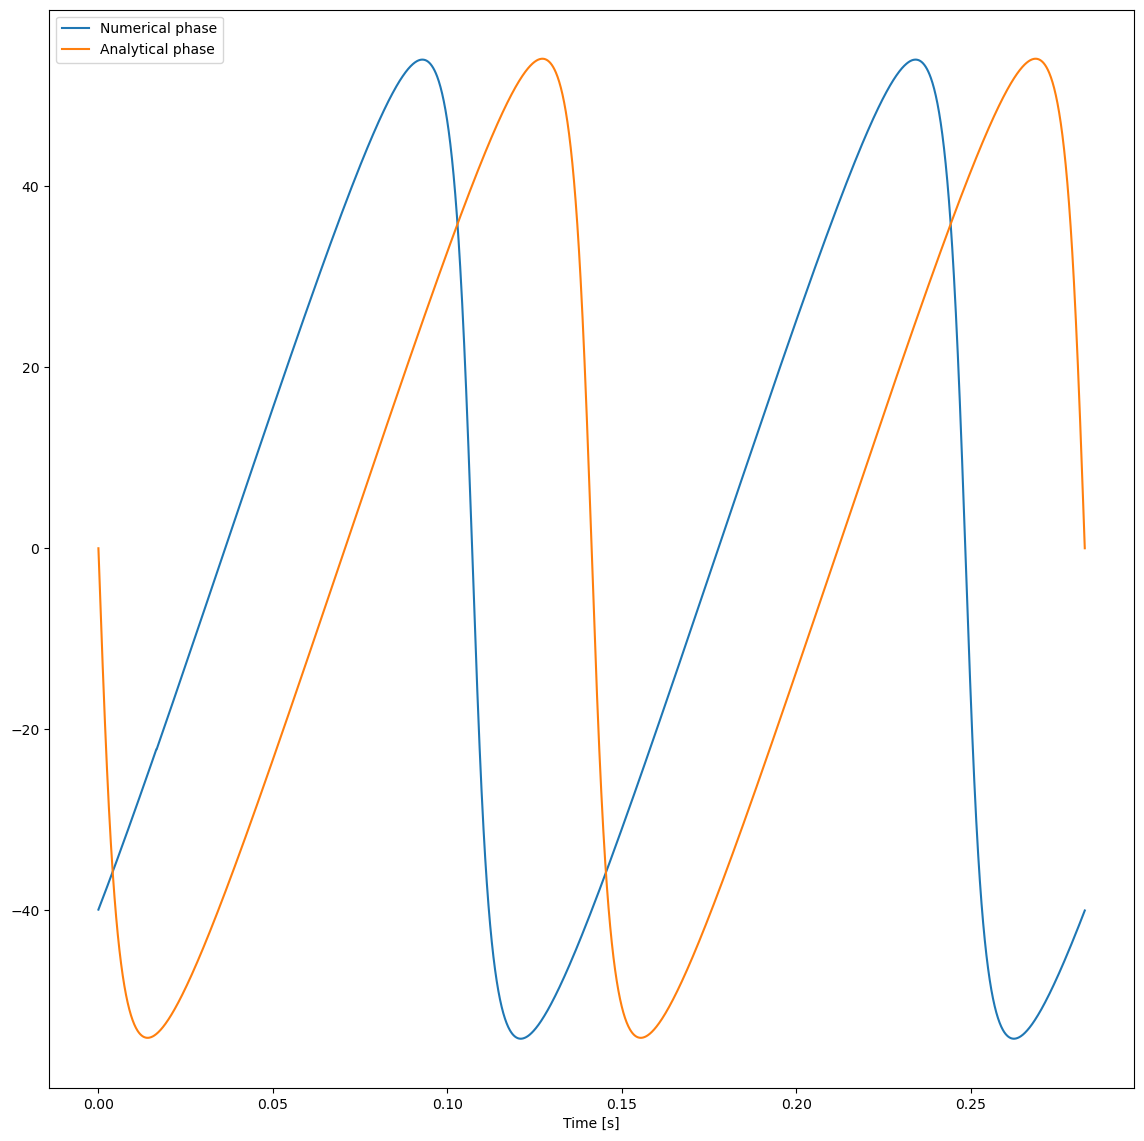

In [51]:
simulation_check3(v, 3000, "linear" )

## Implementation of Eq 2.69

$\LARGE E(t) \approx D_0 e^{-\frac{t}{\tau} - i\frac{kv}{2T} t^2} + \frac{t_a A}{1-r_a r_b e^{-2ikvt}}$

where:

$\LARGE D_0 = t_a A \sqrt{\frac{i \pi}{2kvT}} e^{\frac{iT}{2kv\tau^2}}$

$\tau$ is the storage time

$k$ is the wave number

$v$ is the mirror velocity

$T$ is half of the round-trip time

(Implemented in transient_approx_lib.py)

In [52]:
import transient_approx_lib as tran

## Check if the numerical simulation is computed correctly and it reproduces the cavity ringing.

In [53]:
td = time_window(v_cr(), number_of_points)
res_dyn = E(td, v_cr())
print("res_dyn length: {0}".format(len(res_dyn)))

res_dyn length: 3000


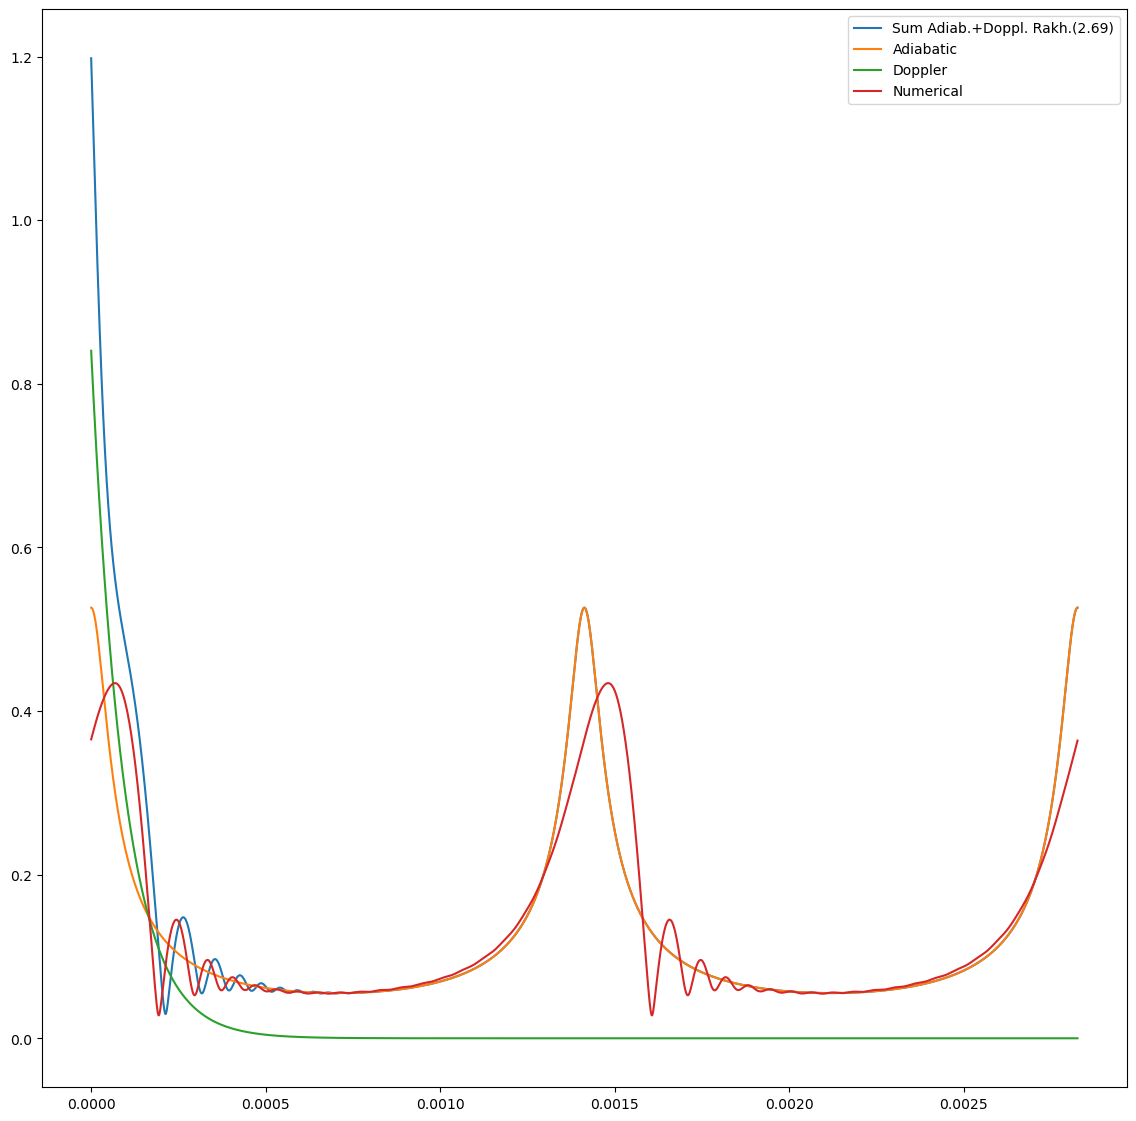

In [54]:
do, ad = tran.E_cr(td, E_in_avg, v_cr(), t_a**2, r_a**2, r_b**2, k, T)
#plt.plot(td, np.abs(ad), label="Adiabatic")
#plt.plot(td, np.abs(do), label="Doppler")
plt.plot(td, np.abs(ad+do), label="Sum Adiab.+Doppl. Rakh.(2.69)")
plt.plot(td, np.abs(ad), label="Adiabatic")
plt.plot(td, np.abs(do), label="Doppler")
roll_factor = -970
res_rolled = np.roll(np.abs(res_dyn), roll_factor)
plt.plot(td, res_rolled, label="Numerical")
plt.legend()
#plt.plot(np.abs(tran.D_0(ein, V)*np.exp(-(time_window(V, 1000)-T)/tau() - complex(0,1)*k*V*np.power((time_window(V, 1000)-T),2)/(2.*T)**2)/gain()))
#plt.plot(np.abs(t_a*ein/(1-r_a*r_b*np.exp(-2.j*k*V*time_window(V, 1000)-T)))/gain())

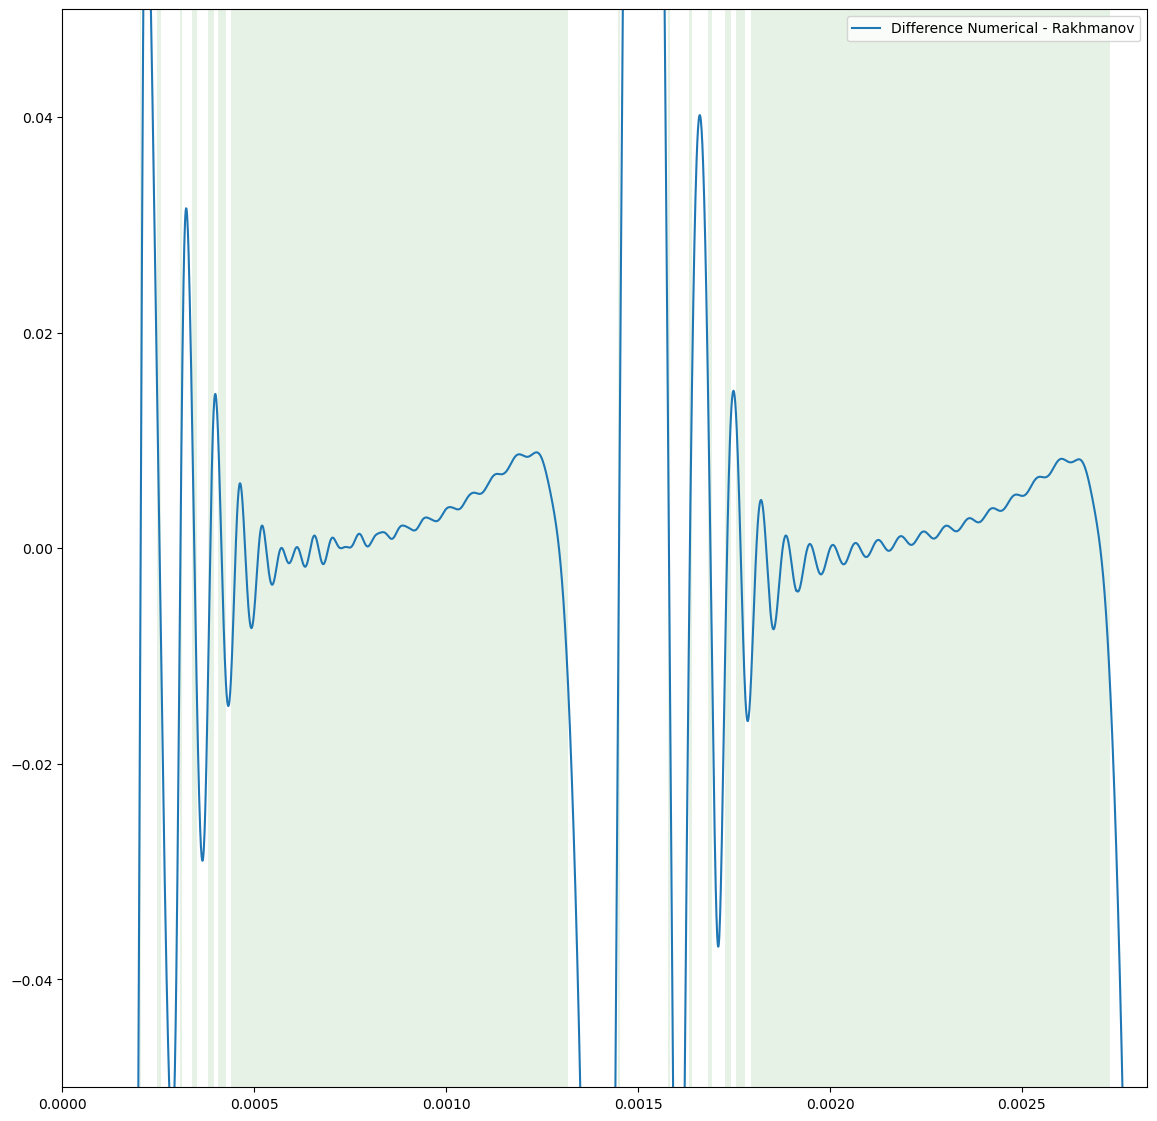

In [55]:
epsilon = 0.012
tdata = time_window(v_cr(),number_of_points)
l = len(tdata)
diffr = np.zeros(l)
good_times_start = []
good_times_stops = []

last_i_start = 0
last_i_stops = 0
for i in range(l):
    diffr[i] = res_rolled[i] - np.abs(ad+do)[i]
    if abs(diffr[i]) < epsilon:
        if last_i_start + 1 != i:
            good_times_start.append(tdata[i])
            #print(tdata[i])
            
        last_i_start = i

    if abs(diffr[i]) > epsilon:
        if last_i_stops + 1 != i:
            good_times_stops.append(tdata[i])
            #print(tdata[i])
            
        last_i_stops = i

for tms in range(len(good_times_start)):
    plt.axvspan(good_times_start[tms], good_times_stops[tms+1], facecolor='green', alpha=0.1)

plt.plot(tdata, diffr, label="Difference Numerical - Rakhmanov")
plt.xlim([0., td[-1]])
plt.ylim([-.05, .05])
plt.legend()

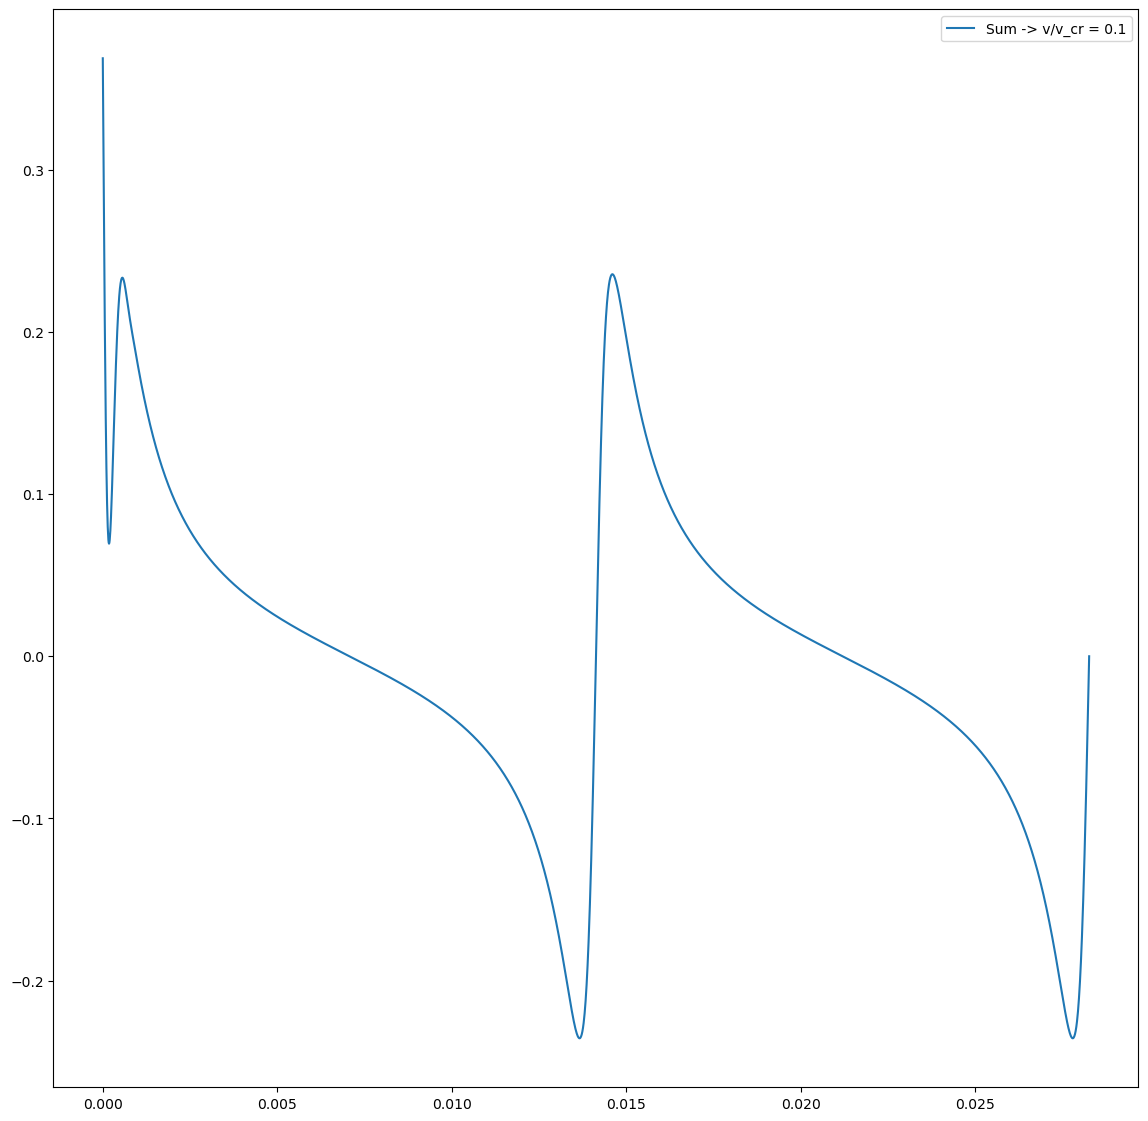

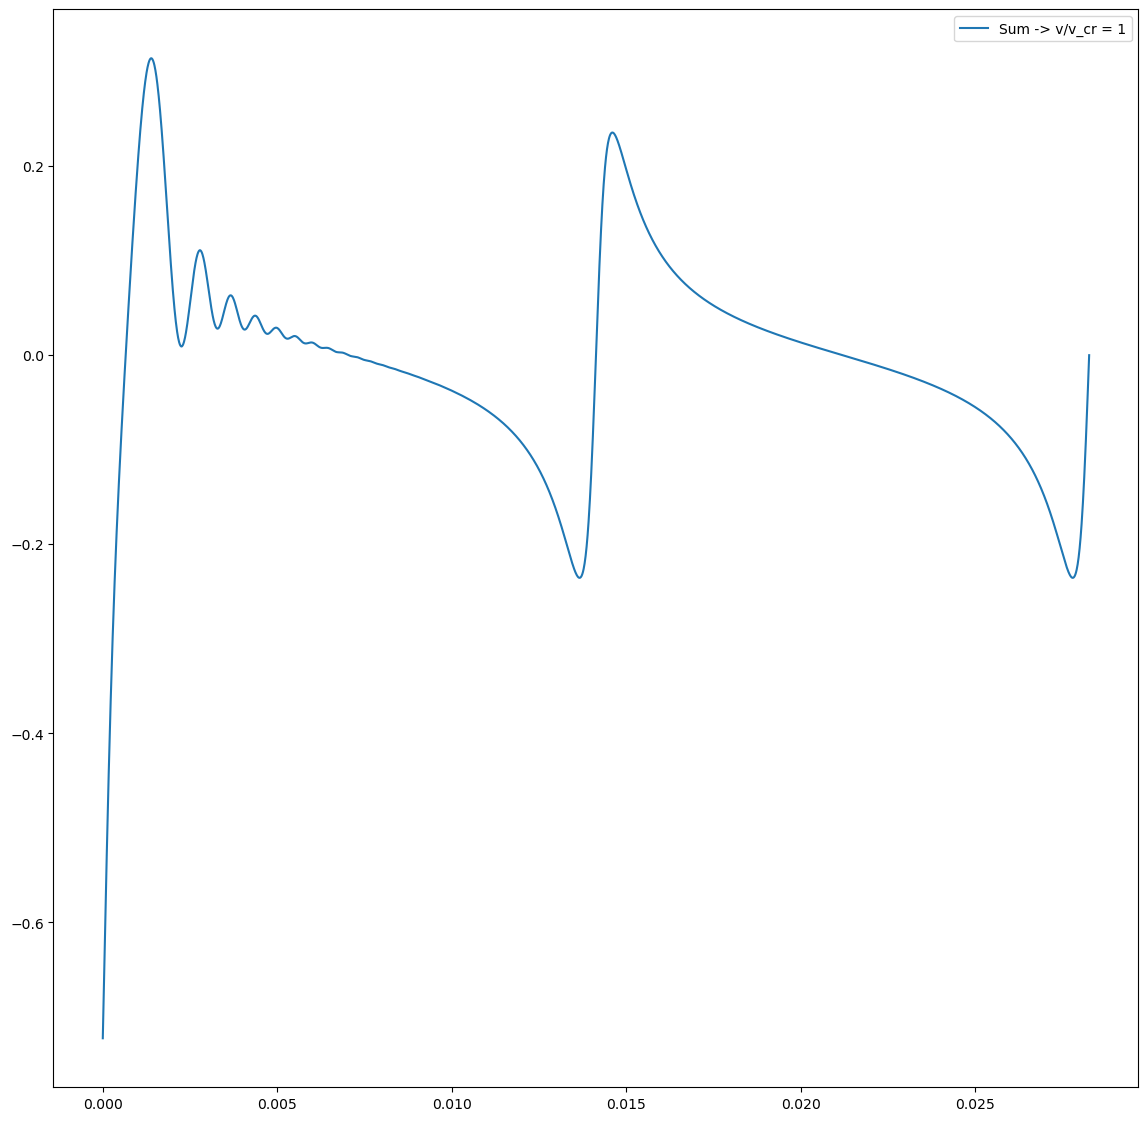

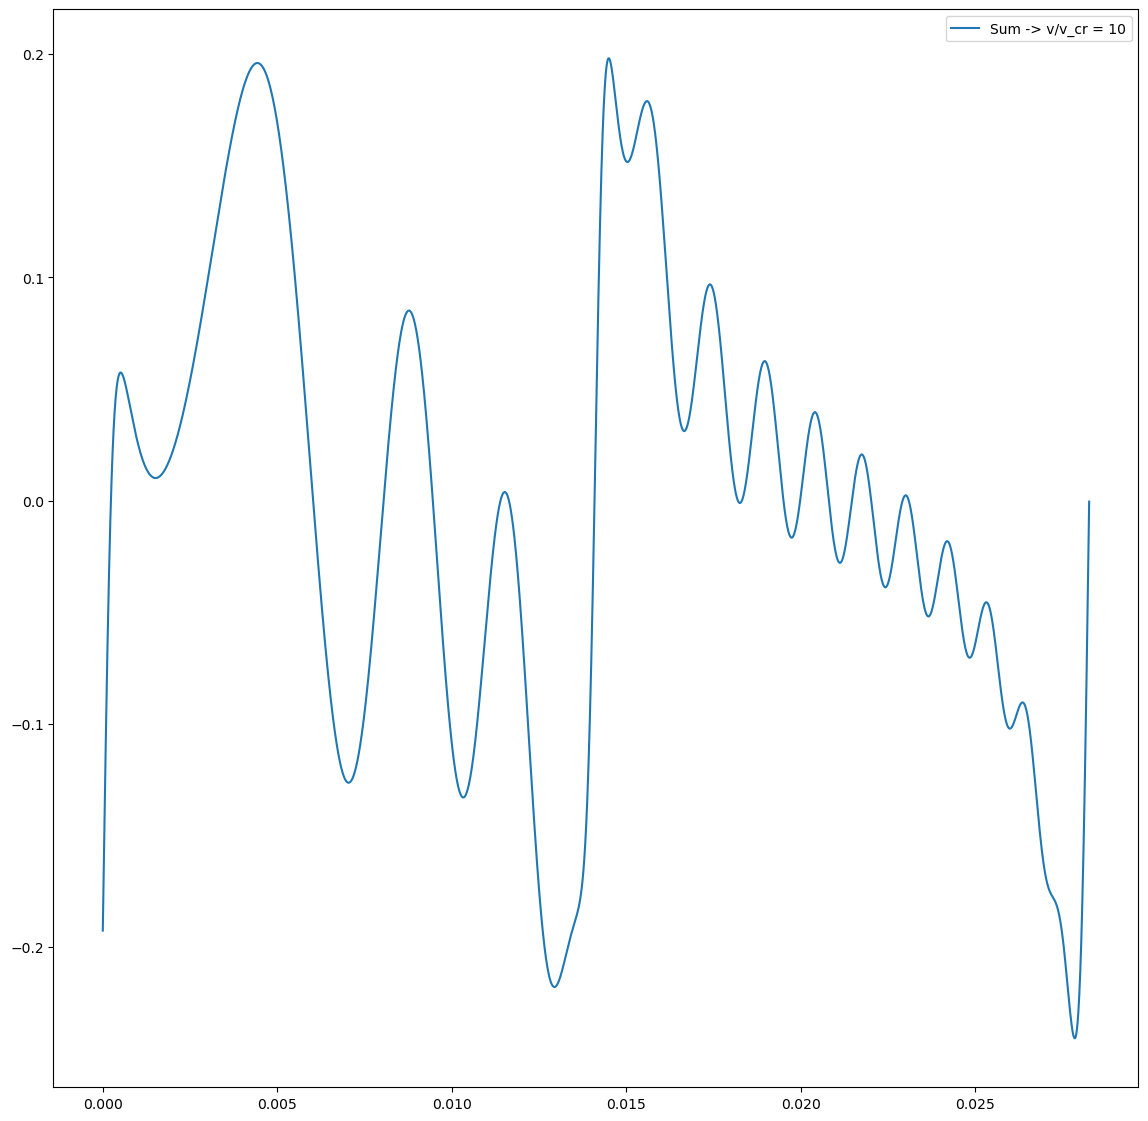

In [56]:
vel = [v_cr()/10., v_cr(), v_cr()*10.]
res_scan = {}
for i, j in zip([0,1,2], vel):
    td = time_window(j,number_of_points)
    do, ad = tran.E_cr(td, E_in_avg, j, t_a**2, r_a**2, r_b**2, k, T)
    res_scan[i] = do + ad

plt.figure()
plt.plot(time_window(v_cr()/10., number_of_points), -res_scan[0].imag, label="Sum -> v/v_cr = 0.1")
plt.legend()
plt.figure()
plt.plot(time_window(v_cr()/10., number_of_points), -res_scan[1].imag, label="Sum -> v/v_cr = 1")
plt.legend()
plt.figure()
plt.plot(time_window(v_cr()/10., number_of_points), -res_scan[2].imag, label="Sum -> v/v_cr = 10")
plt.legend()

plt.show()

# Pound-Drever-Hall

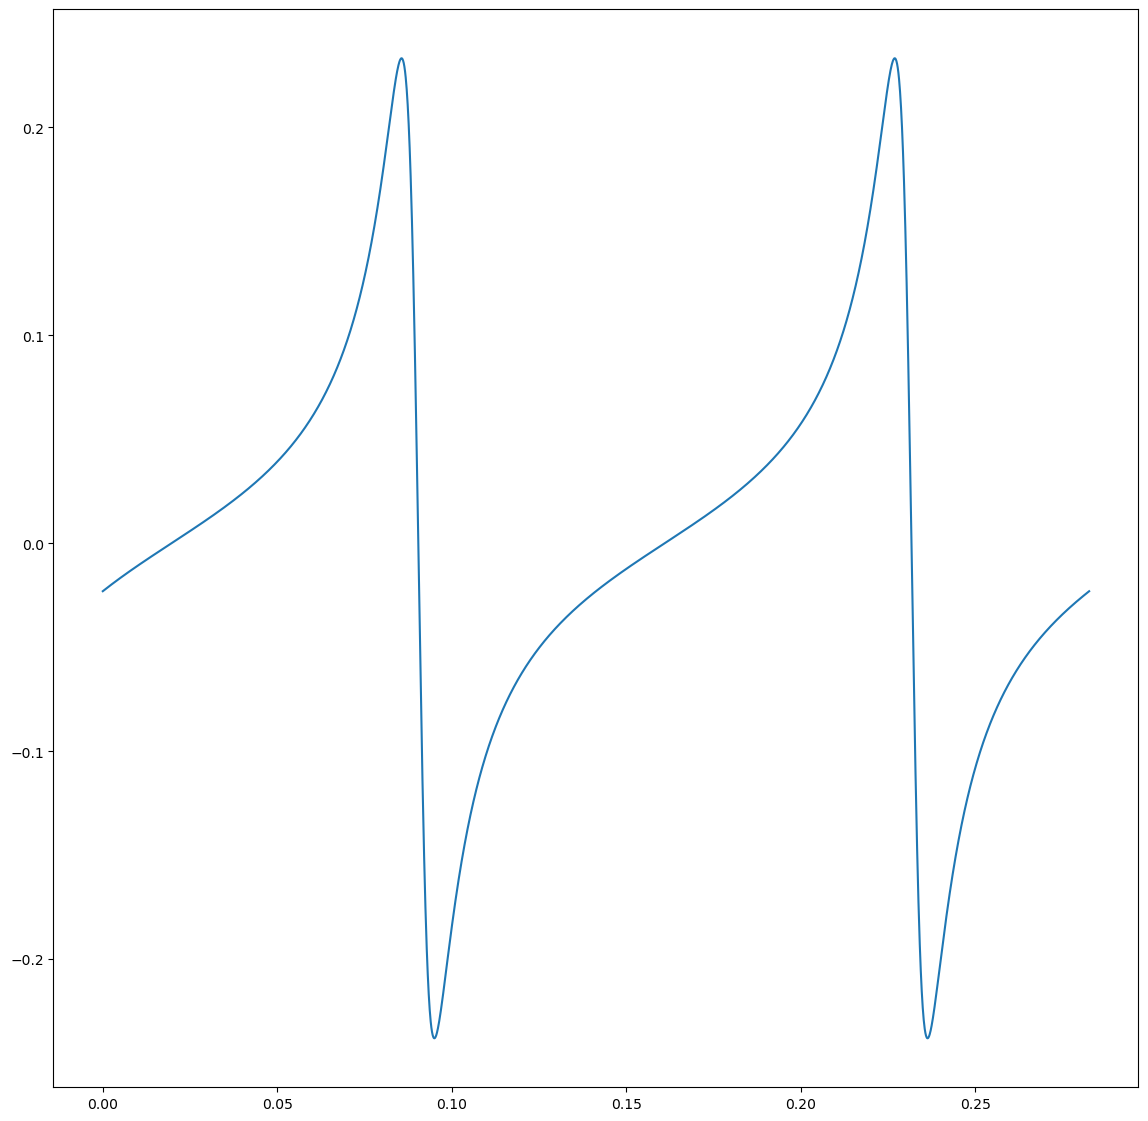

In [57]:
plt.plot(time_window(v, len(res.imag)), res.imag)

## (To-do) Insert expression of $V_{pdh}$

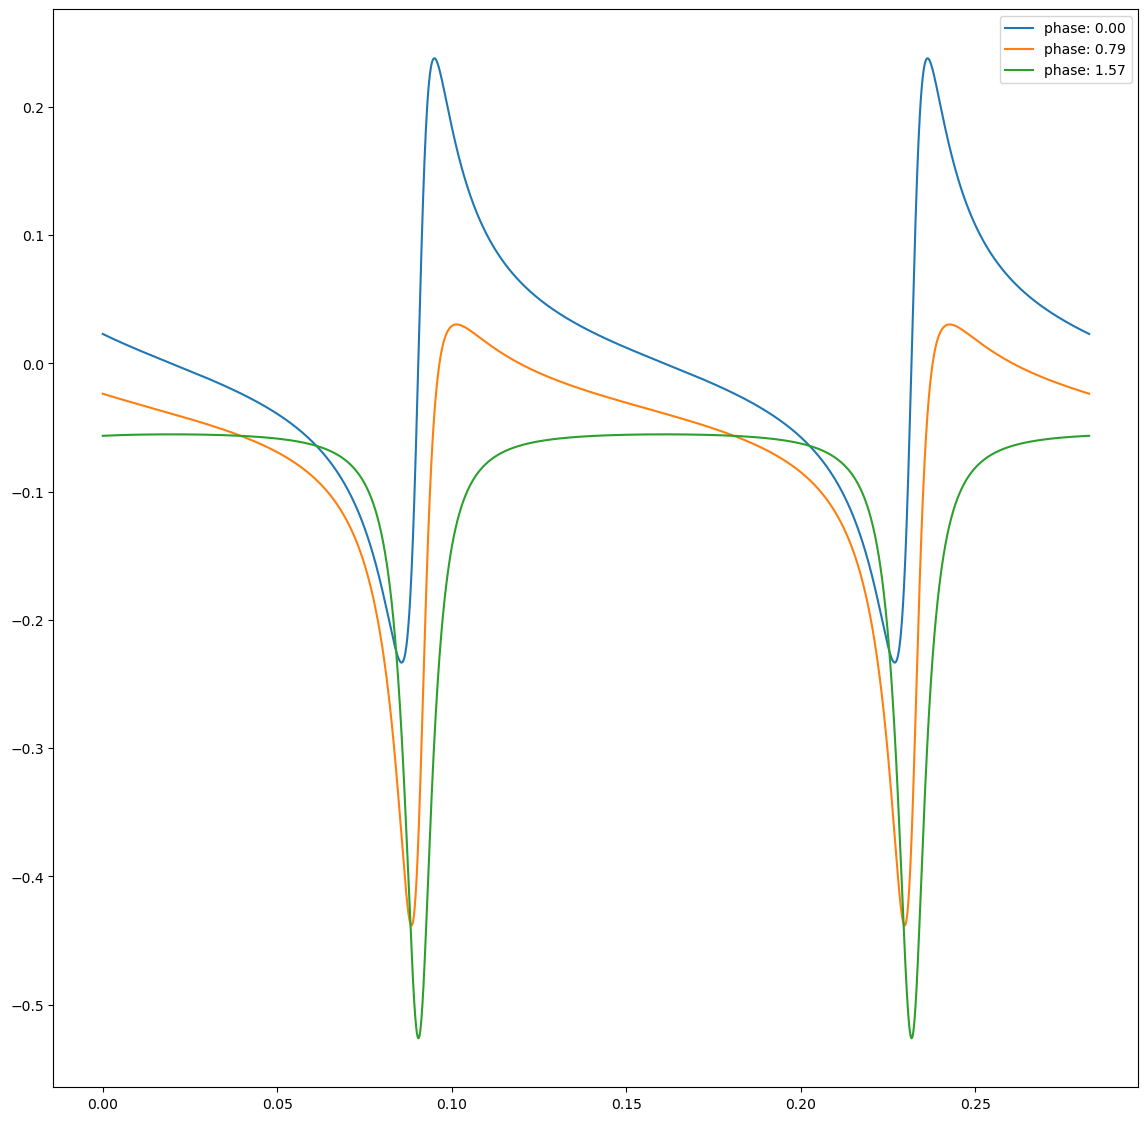

In [58]:
gamma = np.pi/2
def V_pdh(gamma,res):
    return -(np.exp(gamma*1.j) * np.conjugate(ein) * res).imag

for i in np.linspace(0., np.pi/2, 3):
    plt.plot(time_window(v, len(res.imag)), V_pdh(i, res), label="phase: {0:.2f}".format(i))

plt.legend()

In [59]:
def V_pdh_scan(gamma, res):
    return -(np.exp(gamma*1.j) * np.conjugate(ein) * res).imag

0.0
0.7853981633974483
1.5707963267948966


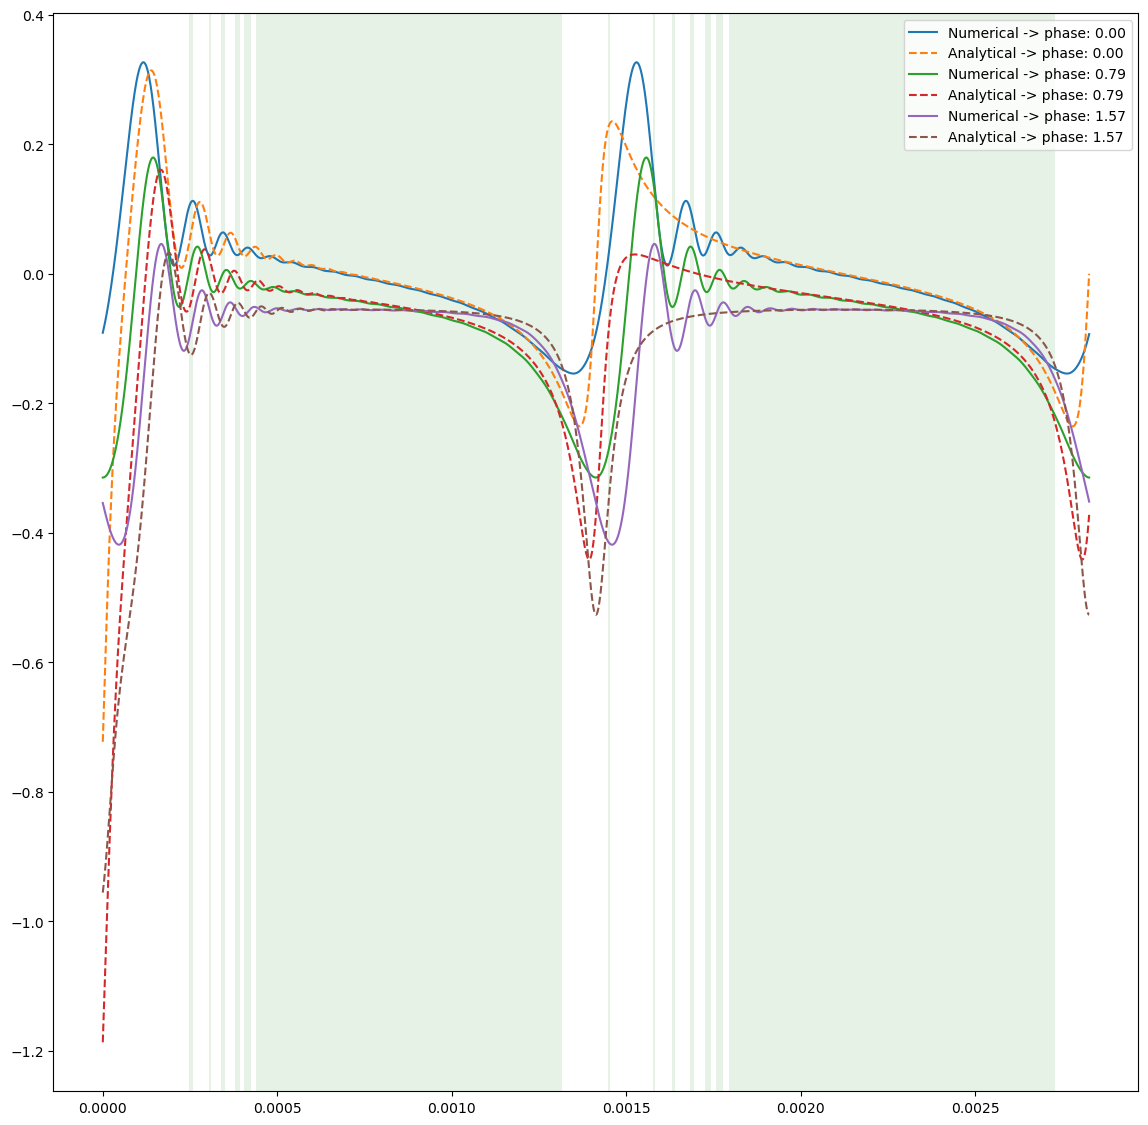

In [60]:
for i in np.linspace(0., np.pi/2, 3):
    plt.plot(time_window(v_cr(), len(res.imag)), V_pdh_scan(i, np.roll(res_dyn,roll_factor)), label="Numerical -> phase: {0:.2f}".format(i))
    plt.plot(time_window(v_cr(), len(res.imag)), V_pdh_scan(i,res_scan[1]),'--', label="Analytical -> phase: {0:.2f}".format(i))
    print(i)
for tms in range(len(good_times_start)):
        plt.axvspan(good_times_start[tms], good_times_stops[tms+1], facecolor='green', alpha=0.1)
plt.legend()

(-0.4, 0.2)

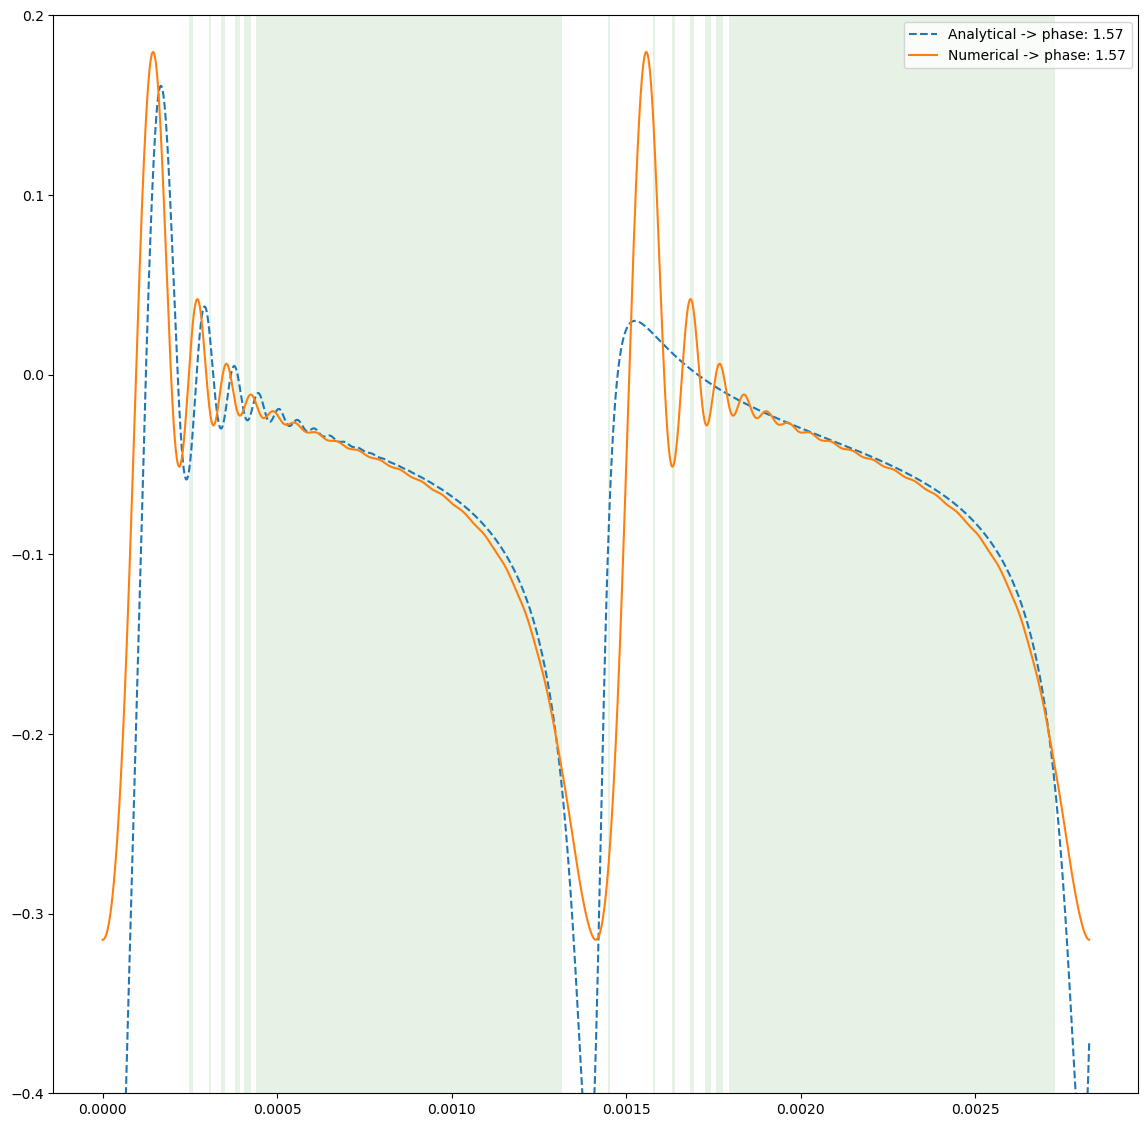

In [61]:
plt.plot(time_window(v_cr(), len(res.imag)), V_pdh_scan(0.7853981633974483,res_scan[1]),'--', label="Analytical -> phase: {0:.2f}".format(i))
plt.plot(time_window(v_cr(), len(res.imag)), V_pdh_scan(0.7853981633974483, np.roll(res_dyn,roll_factor)), label="Numerical -> phase: {0:.2f}".format(i))
for tms in range(len(good_times_start)):
        plt.axvspan(good_times_start[tms], good_times_stops[tms+1], facecolor='green', alpha=0.1)
plt.legend()


plt.ylim(-0.4,0.2)

## Adjusted Pound-Drever signal Eq 2.85

In [62]:
def V_pdh_D(t, v, Ein, gamma):
    t_0=v*lambd/2
    return - Ein*np.abs(D_0(Ein, v))**2*np.exp(t-t_0/tau())*np.sin(gamma+np.angle(D_0(Ein,v))-(k*v*(t-t_0)**2)/(2*T))

In [63]:
def x_a(t):
    return 0.0

## (To-do) Insert Eq 1.48

In [66]:
def E_ref(t, Edt):
    return np.exp(-2.j*k*x_a(t)) * ((r_a**2 + t_a**2)*E_in(t) - t_a * Edt) / r_a #Eq 1.48

tdata = time_window(v, number_of_points)
eref_scan=np.zeros(number_of_points, dtype=np.complex_)
for idx, t in enumerate(tdata):
    ein[idx] = E_in(t)
    res[idx] = E(t,v,N=50)
    eref[idx] = E_ref(t, res[idx])
    eref_scan[idx]=E_ref(t, res_scan[0][idx])

R_coeff = np.roll(eref,roll_factor)/ein
R_coeff_cr=eref_scan/ein

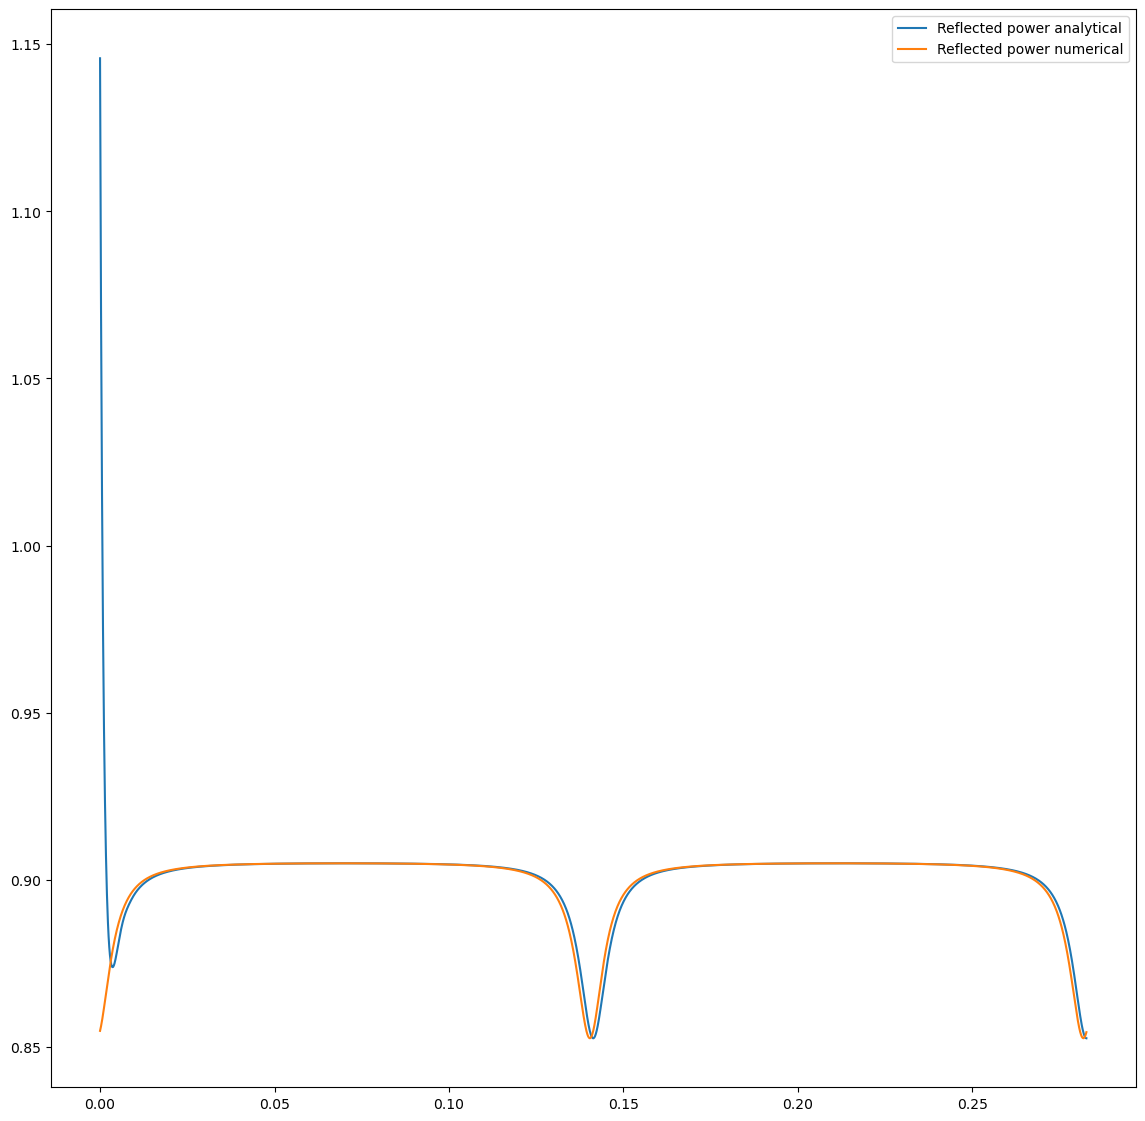

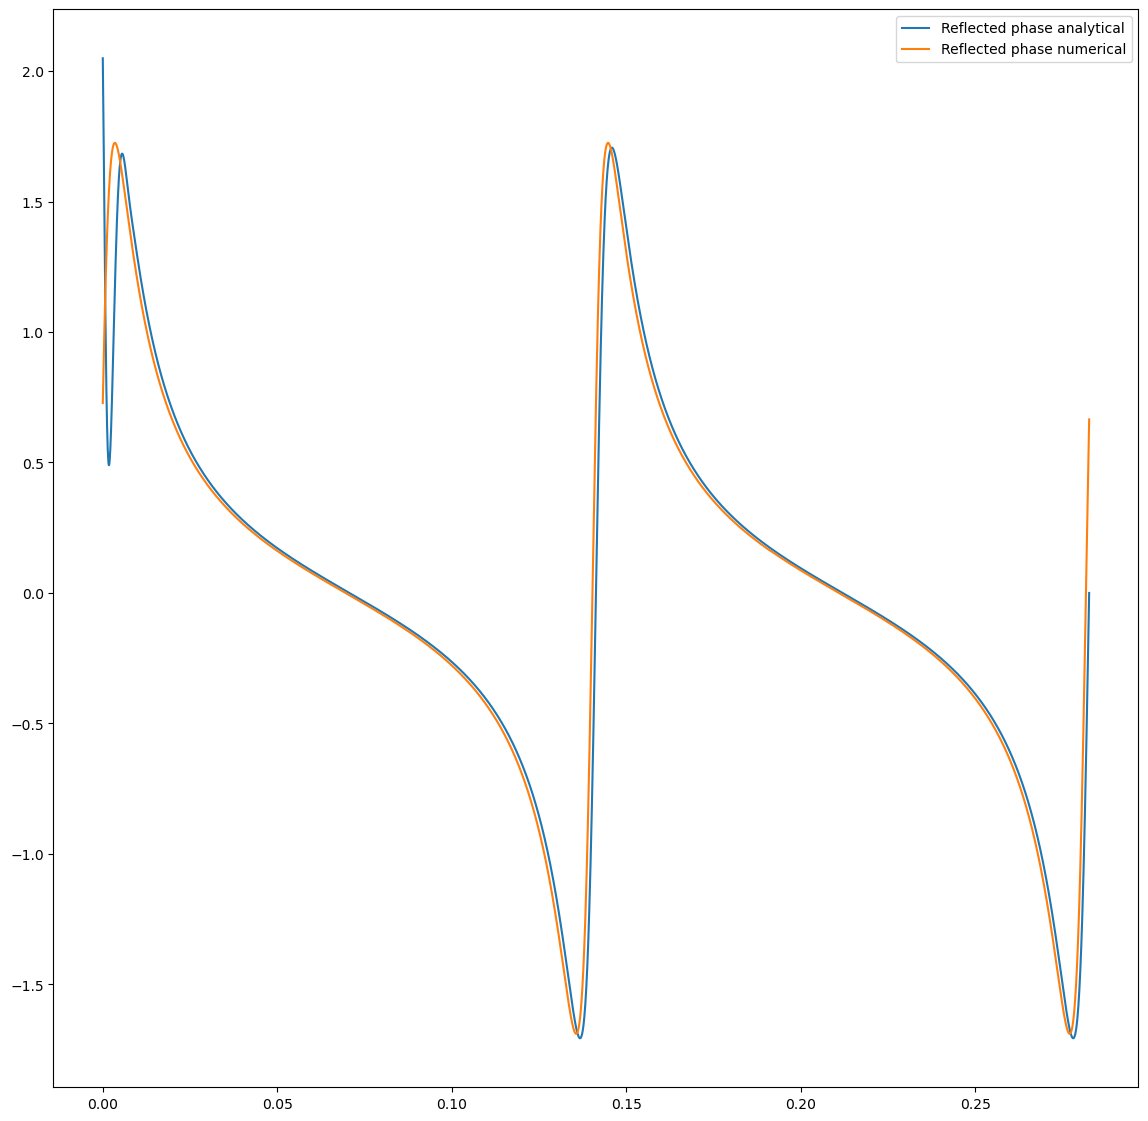

In [67]:
plt.figure()
plt.plot(tdata,np.abs(R_coeff_cr),label="Reflected power analytical")
plt.plot(tdata,np.abs(R_coeff), label="Reflected power numerical")
plt.legend()

plt.figure()
plt.plot(tdata,np.angle(R_coeff_cr,deg=True), label="Reflected phase analytical")
plt.plot(tdata,np.unwrap(np.angle(R_coeff,deg=True)*2)/2, label="Reflected phase numerical")

plt.legend()
plt.show()

# TODO:
    1. Confrontare Reflected power to model in Finesse